# 08 — Pinning the chain

Every other notebook here explains what GRANDlib computes. This one is about
knowing when the answer *changes*, which is a different problem and, during a
refactor, the more pressing one.

The chain has many stages — shower, effective length, galactic noise, the RF
chain, digitisation — and each is checked against something. What was not
checked, until now, is the composition: every stage can be individually
self-consistent while the whole produces different numbers than it did last
month. Nothing in the test suite would have noticed.

A **golden-file regression** is the cheap answer. Run the chain once on a fixed
input with a fixed seed, store the result, and compare against it forever
after.

Be clear about what that is and is not. It **locks in** today's answer; it does
not **validate** it. If the code is wrong today, the reference is wrong too and
the test will happily agree with it. What it buys is that a change to the
answer becomes visible and deliberate rather than silent — which is exactly
what you want before rewriting the thing that produces it.

## The input, and why it looks like that

Three detection units, each carrying the same Gaussian pulse at a different
amplitude on each arm — 1.0, 0.6, 0.2.

The asymmetry is deliberate. If the three arms carried equal amplitudes, then
swapping two of them, or mis-ordering the detection units, would produce
exactly the same output and the regression would pass through the error. Made
asymmetric, any such mistake changes the numbers.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

import tests.sim.test_pipeline_golden as golden

print("seed  ", golden.SEED)
print("params", golden.PARAMS)
print("stored", golden.GOLDEN.name)

seed   0
params {'add_noise': True, 'add_rf_chain': True, 'lst': 18.0}
stored pipeline_golden.npz


## What the stored reference says about itself

The file records the version, commit, seed and configuration that produced it.

That is not bureaucracy. Three galactic-noise tables arrived in this repository
as `.npy` files with no record of how they were made, and closing that gap took
a round trip to their author. A reference file whose whole purpose is to be
compared against is the last place to repeat that.

In [2]:
with np.load(golden.GOLDEN, allow_pickle=False) as data:
    stored = data["voltage"]
    provenance = json.loads(str(data["provenance"]))

print(json.dumps(provenance, indent=2, sort_keys=True))
print()
print("shape", stored.shape, " peak %.1f uV" % np.abs(stored).max())

{
  "commit": "d0778f56ae8c",
  "grandlib_version": "0.1.0.dev1",
  "note": "Reference output of the shower-to-voltage chain. Locks in behaviour; does not validate it. Regenerate only when the answer is meant to change.",
  "params": {
    "add_noise": true,
    "add_rf_chain": true,
    "lst": 18.0
  },
  "seed": 0
}

shape (3, 3, 512)  peak 6063.9 uV


## Running the chain and comparing

Same input, same seed, same configuration. The comparison is bin by bin at a
relative tolerance of $10^{-9}$ — tight enough that any physically meaningful
change fails, loose enough that NumPy reassociating a floating-point sum
between versions does not.

In [3]:
import logging, tempfile, pathlib

# ROOT announces every tree it creates. Four such lines would sit between
# the command below and its answer, so the logger is quietened here.
logging.getLogger("grand").setLevel(logging.ERROR)

fresh = golden._run_chain(pathlib.Path(tempfile.mkdtemp()))

agree = np.allclose(fresh, stored, rtol=1e-9, atol=0.0)
worst = np.abs(fresh - stored).max()
print("reproduces the reference:", agree)
print("largest disagreement:    %.3g uV" % worst)

reproduces the reference: True
largest disagreement:    0 uV


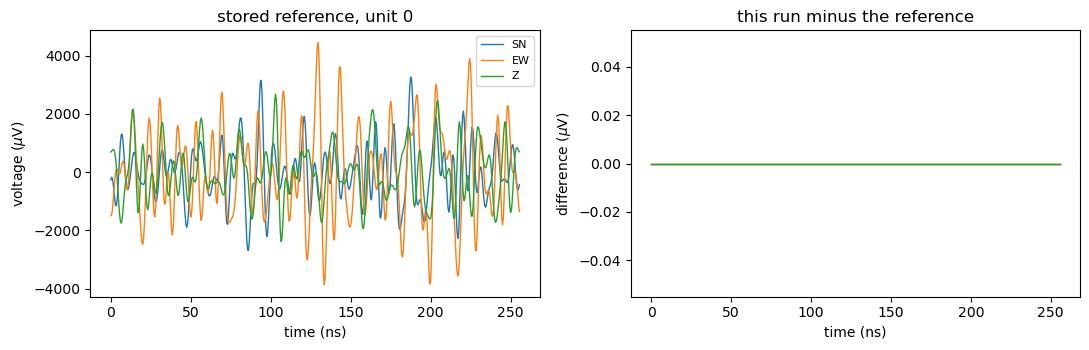

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

t_ns = np.arange(stored.shape[2]) * golden.T_BIN_NS
for arm, name in enumerate(("SN", "EW", "Z")):
    axes[0].plot(t_ns, stored[0, arm], lw=1, label=name)
axes[0].set_xlabel("time (ns)"); axes[0].set_ylabel(r"voltage ($\mu$V)")
axes[0].set_title("stored reference, unit 0"); axes[0].legend(fontsize=8)

axes[1].plot(t_ns, (fresh - stored)[0].T, lw=1)
axes[1].set_xlabel("time (ns)"); axes[1].set_ylabel(r"difference ($\mu$V)")
axes[1].set_title("this run minus the reference")
fig.tight_layout()

The difference panel is flat at exactly zero, not nearly zero. The same seed
on the same platform reproduces the reference bit for bit, so the right-hand
axis has no scale to speak of.

Worth noticing rather than glossing over: the comparison uses a tolerance of
$10^{-9}$, and that margin is there to survive a NumPy or BLAS upgrade
reassociating a floating-point sum, not because anything here needs it today.

## What it catches

The regression is only worth having if it fails when it should. The galactic
noise normalisation moved by $\sqrt2$ on 2026-09-07 — a real change, correctly
made — and that is exactly the size of thing this must not let through.

In [5]:
for label, factor in [("unchanged", 1.0),
                      ("a sqrt(2) normalisation change", np.sqrt(2)),
                      ("a 0.01 % drift", 1.0001),
                      ("one sample nudged by 1 part in a million", None)]:
    if factor is None:
        perturbed = stored.copy()
        perturbed[1, 2, 300] *= 1.000001
    else:
        perturbed = stored * factor
    passes = np.allclose(perturbed, stored, rtol=1e-9, atol=0.0)
    print("%-42s %s" % (label, "passes" if passes else "CAUGHT"))

unchanged                                  passes
a sqrt(2) normalisation change             CAUGHT
a 0.01 % drift                             CAUGHT
one sample nudged by 1 part in a million   CAUGHT


## When to regenerate it

Rarely, and never casually:

```
python tests/sim/test_pipeline_golden.py --write
```

Do that only when the answer is *meant* to change — a corrected constant, a new
antenna model, a deliberate change to the chain — and say why in the commit
message. The stored provenance then records which version produced the new
reference, so the next person can see what they are comparing against.

If the test fails and you did not intend a change, that is the regression doing
its job. Find out what moved before regenerating; regenerating first destroys
the evidence.

## What this does not do

It does not tell you the chain is correct. Nothing in this repository does,
end to end — the closest we have is the galactic-noise level, which is rebuilt
from the shipped tables and the documented relation and agrees exactly
(notebook 05).

An external check would mean reproducing a published figure, which needs the
inputs behind it to still exist. Until then, this is what stands between a
refactor and a silently different answer.

## Where next

- [06 — From electric field to ADC](06_efield_to_adc.ipynb) — the chain being pinned here
- [05 — Galactic noise](05_galactic_noise.ipynb) — the one stage that is checked against its own inputs
- [04 — The RF chain](04_rf_chain.ipynb) — where most of the shape comes from